# Field Diagnostics: Drifting vs R3GAN-Induced Field

这个 notebook 直接调用仓库里已有的函数，把两类 sample-space field 放在同一个 2D toy setup 里对照：

- `training.drift_field.compute_v` 对应 **Drifting** 的显式向量场
- `training.loss` 里的 pairwise / local-coupled generator helper 对应 **R3GAN / RankGAN** 的 critic-induced field

这里我们关心的不是最终 loss，而是：**给定同一批 real / fake 样本，它们分别想把 fake 往哪儿推。**

In [1]:
import math
import sys
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception:
    pd = None
    HAS_PANDAS = False

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from training.drift_field import DriftFieldConfig, compute_v
from training.loss import (
    build_local_coupling,
    pairwise_delta,
    pairwise_generator_loss,
    local_coupled_generator_loss_with_grads,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["axes.grid"] = False
print("device:", DEVICE)


device: cuda


In [2]:
def sample_ring_mixture(
    n: int,
    *,
    radius: float = 2.0,
    std: float = 0.10,
    components: int = 8,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    angles = torch.linspace(0, 2 * math.pi, components + 1, device=device)[:-1]
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], dim=1)
    ids = torch.randint(0, components, (n,), device=device)
    noise = torch.randn(n, 2, device=device) * std
    return centers[ids] + noise


def sample_two_moons(
    n: int,
    *,
    noise: float = 0.08,
    scale: float = 1.6,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    n1 = n // 2
    n2 = n - n1
    theta1 = torch.rand(n1, device=device) * math.pi
    theta2 = torch.rand(n2, device=device) * math.pi
    moon1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=1)
    moon2 = torch.stack([1.0 - torch.cos(theta2), -torch.sin(theta2) - 0.5], dim=1)
    data = torch.cat([moon1, moon2], dim=0)
    data = data * scale
    data = data + torch.randn_like(data) * noise
    data = data - data.mean(dim=0, keepdim=True)
    return data


def sample_checkerboard(
    n: int,
    *,
    extent: float = 2.4,
    cell_size: float = 0.8,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    points = []
    target = n
    while sum(p.shape[0] for p in points) < target:
        cand = torch.empty(target * 2, 2, device=device).uniform_(-extent, extent)
        gx = torch.floor((cand[:, 0] + extent) / cell_size).long()
        gy = torch.floor((cand[:, 1] + extent) / cell_size).long()
        mask = ((gx + gy) % 2) == 0
        accepted = cand[mask]
        if accepted.numel() > 0:
            points.append(accepted)
    return torch.cat(points, dim=0)[:target]


def sample_spiral(
    n: int,
    *,
    noise: float = 0.06,
    turns: float = 2.8,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    n1 = n // 2
    n2 = n - n1
    t1 = torch.sqrt(torch.rand(n1, device=device)) * turns * math.pi
    t2 = torch.sqrt(torch.rand(n2, device=device)) * turns * math.pi
    r1 = 0.18 * t1 + 0.2
    r2 = 0.18 * t2 + 0.2
    arm1 = torch.stack([r1 * torch.cos(t1), r1 * torch.sin(t1)], dim=1)
    arm2 = torch.stack([r2 * torch.cos(t2 + math.pi), r2 * torch.sin(t2 + math.pi)], dim=1)
    data = torch.cat([arm1, arm2], dim=0)
    data = data + torch.randn_like(data) * noise
    data = data - data.mean(dim=0, keepdim=True)
    return data * 0.9


SCENARIOS: dict[str, Callable[..., torch.Tensor]] = {
    "ring": sample_ring_mixture,
    "two_moons": sample_two_moons,
    "checkerboard": sample_checkerboard,
    "spiral": sample_spiral,
}


def sample_real_distribution(name: str, n: int, *, device: torch.device = DEVICE) -> torch.Tensor:
    if name not in SCENARIOS:
        raise ValueError(f"unknown scenario: {name}")
    return SCENARIOS[name](n, device=device)


def sample_fake_init(
    n: int,
    *,
    center=(0.0, 0.0),
    std: float = 0.75,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    center_t = torch.tensor(center, device=device, dtype=torch.float32)
    return center_t + torch.randn(n, 2, device=device) * std


def per_sample_cosine_tensor(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    a_n = a / a.norm(dim=1, keepdim=True).clamp_min(eps)
    b_n = b / b.norm(dim=1, keepdim=True).clamp_min(eps)
    return (a_n * b_n).sum(dim=1)


def mean_cosine(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-8) -> float:
    return float(per_sample_cosine_tensor(a, b, eps=eps).mean().item())


def safe_ratio(num: torch.Tensor, denom: torch.Tensor, *, eps: float = 1e-8, clip_max: float | None = None) -> torch.Tensor:
    ratio = num / denom.clamp_min(eps)
    if clip_max is not None:
        ratio = ratio.clamp(max=clip_max)
    return ratio


def summarize_vector(values: torch.Tensor) -> dict[str, float]:
    values = values.detach().to(torch.float32)
    return {
        "mean": float(values.mean().item()),
        "median": float(values.median().item()),
        "p10": float(torch.quantile(values, 0.10).item()),
        "p90": float(torch.quantile(values, 0.90).item()),
    }


def field_stats(field: torch.Tensor) -> dict[str, float]:
    norms = field.norm(dim=1)
    return {
        "mean_norm": float(norms.mean().item()),
        "median_norm": float(norms.median().item()),
        "max_norm": float(norms.max().item()),
    }


def compute_plot_bounds(*tensors: torch.Tensor, pad: float = 0.6) -> tuple[tuple[float, float], tuple[float, float]]:
    cat = torch.cat([t.detach().reshape(-1, 2).cpu() for t in tensors], dim=0)
    mins = cat.min(dim=0).values
    maxs = cat.max(dim=0).values
    xlim = (float(mins[0] - pad), float(maxs[0] + pad))
    ylim = (float(mins[1] - pad), float(maxs[1] + pad))
    return xlim, ylim


def compute_knn_transport_vectors(fake: torch.Tensor, real: torch.Tensor, *, k: int = 4) -> torch.Tensor:
    dist = torch.cdist(fake, real)
    k = min(k, real.shape[0])
    nn_idx = dist.topk(k, largest=False).indices
    centers = real[nn_idx].mean(dim=1)
    return centers - fake


In [3]:
class ToyCritic(nn.Module):
    def __init__(self, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).reshape(-1)


def fit_toy_critic(
    real: torch.Tensor,
    fake: torch.Tensor,
    *,
    steps: int = 600,
    lr: float = 2e-3,
    hidden_dim: int = 128,
) -> ToyCritic:
    critic = ToyCritic(hidden_dim=hidden_dim).to(real.device)
    optimizer = torch.optim.Adam(critic.parameters(), lr=lr)
    for _ in range(steps):
        real_logits = critic(real)
        fake_logits = critic(fake)
        loss = F.softplus(-real_logits).mean() + F.softplus(fake_logits).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    critic.eval()
    return critic


def plot_critic_background(
    ax,
    critic: nn.Module,
    *,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    steps: int = 180,
):
    xs = torch.linspace(xlim[0], xlim[1], steps, device=DEVICE)
    ys = torch.linspace(ylim[0], ylim[1], steps, device=DEVICE)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    with torch.no_grad():
        zz = critic(grid).reshape(steps, steps).detach().cpu().numpy()
    ax.contourf(xx.detach().cpu().numpy(), yy.detach().cpu().numpy(), zz, levels=24, cmap="RdBu_r", alpha=0.22)


In [4]:
def compute_explicit_drift_field(fake: torch.Tensor, real: torch.Tensor, *, temperature: float = 0.35) -> torch.Tensor:
    cfg = DriftFieldConfig(temperature=temperature)
    return compute_v(
        x=fake,
        y_pos=real,
        y_neg=fake,
        config=cfg,
        generated_negative_count=fake.shape[0],
    )


def score_grad_to_sample_field(fake: torch.Tensor, critic: nn.Module, grad_fake_scores: torch.Tensor) -> torch.Tensor:
    fake_var = fake.detach().clone().requires_grad_(True)
    fake_scores = critic(fake_var)
    grad_x = torch.autograd.grad(
        outputs=fake_scores,
        inputs=fake_var,
        grad_outputs=grad_fake_scores.to(fake_scores.dtype),
    )[0]
    return (-grad_x).detach()


def compute_pairwise_induced_field(fake: torch.Tensor, real: torch.Tensor, critic: nn.Module, *, margin: float = 0.0):
    with torch.no_grad():
        real_scores = critic(real)
        fake_scores = critic(fake)
    fake_scores_var = fake_scores.detach().clone().requires_grad_(True)
    pair_loss = pairwise_generator_loss(
        pairwise_delta(real_scores, fake_scores_var),
        margin=margin,
    ).mean()
    grad_fake_scores = torch.autograd.grad(pair_loss, fake_scores_var)[0].detach()
    field = score_grad_to_sample_field(fake, critic, grad_fake_scores)
    return field, grad_fake_scores


def compute_local_coupled_induced_field(
    fake: torch.Tensor,
    real: torch.Tensor,
    critic: nn.Module,
    *,
    coupling_k: int = 4,
    lambda_pair: float = 1.0,
    lambda_list: float = 0.5,
    pair_margin: float = 0.0,
    list_tau: float = 0.20,
):
    with torch.no_grad():
        real_scores = critic(real)
        fake_scores = critic(fake)
    neighbor_indices, coupling_weights, coupling_info = build_local_coupling(
        real,
        fake,
        k=coupling_k,
        return_info=True,
    )
    _, _, grad_fake_scores = local_coupled_generator_loss_with_grads(
        real_scores,
        fake_scores,
        neighbor_indices,
        coupling_weights,
        lambda_pair=lambda_pair,
        pair_margin=pair_margin,
        lambda_list=lambda_list,
        list_tau=list_tau,
    )
    field = score_grad_to_sample_field(fake, critic, grad_fake_scores)
    return field, coupling_info


In [5]:
def run_field_diagnostics(
    scenario: str = "ring",
    *,
    seed: int = 7,
    n_real: int = 256,
    n_fake: int = 256,
    fake_std: float = 0.70,
    drift_temperature: float = 0.35,
    coupling_k: int = 4,
    transport_k: int = 4,
    lambda_pair: float = 1.0,
    lambda_list: float = 0.5,
    pair_margin: float = 0.0,
    list_tau: float = 0.20,
    critic_steps: int = 700,
    critic_lr: float = 2e-3,
    critic_hidden_dim: int = 128,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    real = sample_real_distribution(scenario, n_real, device=DEVICE)
    fake = sample_fake_init(n_fake, std=fake_std, device=DEVICE)
    critic = fit_toy_critic(
        real,
        fake,
        steps=critic_steps,
        lr=critic_lr,
        hidden_dim=critic_hidden_dim,
    )

    drift_field = compute_explicit_drift_field(fake, real, temperature=drift_temperature)
    pair_field, pair_grad_scores = compute_pairwise_induced_field(fake, real, critic, margin=pair_margin)
    local_field, coupling_info = compute_local_coupled_induced_field(
        fake,
        real,
        critic,
        coupling_k=coupling_k,
        lambda_pair=lambda_pair,
        lambda_list=lambda_list,
        pair_margin=pair_margin,
        list_tau=list_tau,
    )
    transport_vectors = compute_knn_transport_vectors(fake, real, k=transport_k)

    pair_drift_cos = per_sample_cosine_tensor(drift_field, pair_field)
    local_drift_cos = per_sample_cosine_tensor(drift_field, local_field)
    pair_local_cos = per_sample_cosine_tensor(pair_field, local_field)

    drift_transport_cos = per_sample_cosine_tensor(drift_field, transport_vectors)
    pair_transport_cos = per_sample_cosine_tensor(pair_field, transport_vectors)
    local_transport_cos = per_sample_cosine_tensor(local_field, transport_vectors)

    pair_norm = pair_field.norm(dim=1)
    local_norm = local_field.norm(dim=1)
    drift_norm = drift_field.norm(dim=1)
    local_over_pair_ratio = safe_ratio(local_norm, pair_norm, clip_max=20.0)

    xlim, ylim = compute_plot_bounds(real, fake)

    summary = {
        "scenario": scenario,
        "drift_mean_norm": float(drift_norm.mean().item()),
        "pair_mean_norm": float(pair_norm.mean().item()),
        "local_mean_norm": float(local_norm.mean().item()),
        "drift_pair_cos": float(pair_drift_cos.mean().item()),
        "drift_local_cos": float(local_drift_cos.mean().item()),
        "pair_local_cos": float(pair_local_cos.mean().item()),
        "drift_transport_cos": float(drift_transport_cos.mean().item()),
        "pair_transport_cos": float(pair_transport_cos.mean().item()),
        "local_transport_cos": float(local_transport_cos.mean().item()),
        "local_over_pair_mean_ratio": float(local_over_pair_ratio.mean().item()),
        "local_over_pair_median_ratio": float(local_over_pair_ratio.median().item()),
        "mean_effective_neighbors": float(coupling_info["effective_neighbors"].mean().item()),
        "mean_weight_entropy": float(coupling_info["weight_entropy"].mean().item()),
        "mean_abs_pair_score_grad": float(pair_grad_scores.abs().mean().item()),
    }

    return {
        "scenario": scenario,
        "real": real,
        "fake": fake,
        "critic": critic,
        "drift_field": drift_field,
        "pair_field": pair_field,
        "local_field": local_field,
        "transport_vectors": transport_vectors,
        "pair_drift_cos": pair_drift_cos,
        "local_drift_cos": local_drift_cos,
        "pair_local_cos": pair_local_cos,
        "drift_transport_cos": drift_transport_cos,
        "pair_transport_cos": pair_transport_cos,
        "local_transport_cos": local_transport_cos,
        "local_over_pair_ratio": local_over_pair_ratio,
        "coupling_info": coupling_info,
        "summary": summary,
        "xlim": xlim,
        "ylim": ylim,
    }


def print_run_summary(result: dict):
    summary = result["summary"]
    print(f"scenario: {summary['scenario']}")
    print("field mean norms:")
    print({
        "drift": round(summary["drift_mean_norm"], 4),
        "pair": round(summary["pair_mean_norm"], 4),
        "local": round(summary["local_mean_norm"], 4),
    })
    print("alignment to explicit drift:")
    print({
        "pair": round(summary["drift_pair_cos"], 4),
        "local": round(summary["drift_local_cos"], 4),
        "pair_vs_local": round(summary["pair_local_cos"], 4),
    })
    print("alignment to kNN transport vectors:")
    print({
        "drift": round(summary["drift_transport_cos"], 4),
        "pair": round(summary["pair_transport_cos"], 4),
        "local": round(summary["local_transport_cos"], 4),
    })
    print("mobility:")
    print({
        "local_over_pair_mean": round(summary["local_over_pair_mean_ratio"], 4),
        "local_over_pair_median": round(summary["local_over_pair_median_ratio"], 4),
    })
    print("coupling:")
    print({
        "effective_neighbors": round(summary["mean_effective_neighbors"], 4),
        "weight_entropy": round(summary["mean_weight_entropy"], 4),
    })


In [6]:
def plot_field(
    ax,
    real: torch.Tensor,
    fake: torch.Tensor,
    field: torch.Tensor,
    *,
    title: str,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    critic: nn.Module | None = None,
    max_arrows: int = 96,
    scale: float = 8.0,
):
    if critic is not None:
        plot_critic_background(ax, critic, xlim=xlim, ylim=ylim)
    plot_count = min(max_arrows, fake.shape[0])
    idx = torch.randperm(fake.shape[0], device=fake.device)[:plot_count]
    real_np = real.detach().cpu().numpy()
    fake_np = fake.detach().cpu().numpy()
    field_np = field.detach().cpu().numpy()
    idx_np = idx.detach().cpu().numpy()
    ax.scatter(real_np[:, 0], real_np[:, 1], s=12, c="#1f77b4", alpha=0.55, label="real")
    ax.scatter(fake_np[:, 0], fake_np[:, 1], s=12, c="#ff7f0e", alpha=0.60, label="fake")
    ax.quiver(
        fake_np[idx_np, 0],
        fake_np[idx_np, 1],
        field_np[idx_np, 0],
        field_np[idx_np, 1],
        angles="xy",
        scale_units="xy",
        scale=scale,
        color="#222222",
        width=0.0038,
        alpha=0.92,
    )
    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")


def plot_field_triptych(result: dict):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), constrained_layout=True)
    plot_field(
        axes[0],
        result["real"],
        result["fake"],
        result["drift_field"],
        title="Explicit Drift Field",
        xlim=result["xlim"],
        ylim=result["ylim"],
        critic=None,
        scale=7.5,
    )
    plot_field(
        axes[1],
        result["real"],
        result["fake"],
        result["pair_field"],
        title="R3GAN Pairwise-Induced Field",
        xlim=result["xlim"],
        ylim=result["ylim"],
        critic=result["critic"],
        scale=10.0,
    )
    plot_field(
        axes[2],
        result["real"],
        result["fake"],
        result["local_field"],
        title="R3GAN Local-Coupled Field",
        xlim=result["xlim"],
        ylim=result["ylim"],
        critic=result["critic"],
        scale=10.0,
    )
    axes[0].legend(loc="upper right")
    plt.show()


def plot_scalar_diagnostics(result: dict):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), constrained_layout=True)

    axes[0].hist(result["pair_drift_cos"].detach().cpu().numpy(), bins=24, color="#ff7f0e", alpha=0.85)
    axes[0].axvline(float(result["summary"]["drift_pair_cos"]), color="black", linestyle="--", linewidth=1.5)
    axes[0].set_title("Per-sample cos: drift vs pair")
    axes[0].set_xlabel("cosine")

    axes[1].hist(result["local_drift_cos"].detach().cpu().numpy(), bins=24, color="#2ca02c", alpha=0.85)
    axes[1].axvline(float(result["summary"]["drift_local_cos"]), color="black", linestyle="--", linewidth=1.5)
    axes[1].set_title("Per-sample cos: drift vs local")
    axes[1].set_xlabel("cosine")

    axes[2].hist(result["local_over_pair_ratio"].detach().cpu().numpy(), bins=24, color="#9467bd", alpha=0.85)
    axes[2].axvline(1.0, color="black", linestyle="--", linewidth=1.2)
    axes[2].set_title("Mobility ratio: ||local|| / ||pair||")
    axes[2].set_xlabel("ratio")

    axes[3].hist(result["drift_transport_cos"].detach().cpu().numpy(), bins=24, alpha=0.45, label="drift", color="#1f77b4")
    axes[3].hist(result["pair_transport_cos"].detach().cpu().numpy(), bins=24, alpha=0.45, label="pair", color="#ff7f0e")
    axes[3].hist(result["local_transport_cos"].detach().cpu().numpy(), bins=24, alpha=0.45, label="local", color="#2ca02c")
    axes[3].set_title("Alignment to kNN transport vectors")
    axes[3].set_xlabel("cosine")
    axes[3].legend(loc="upper left")

    plt.show()


def plot_sweep_bars(summary_rows: list[dict]):
    names = [row["scenario"] for row in summary_rows]
    x = np.arange(len(names))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)

    axes[0].bar(x - 0.16, [row["drift_pair_cos"] for row in summary_rows], width=0.32, label="drift vs pair", color="#ff7f0e")
    axes[0].bar(x + 0.16, [row["drift_local_cos"] for row in summary_rows], width=0.32, label="drift vs local", color="#2ca02c")
    axes[0].set_xticks(x, names, rotation=20)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title("Mean alignment to explicit drift")
    axes[0].legend(loc="upper left")

    axes[1].bar(x - 0.22, [row["drift_transport_cos"] for row in summary_rows], width=0.22, label="drift", color="#1f77b4")
    axes[1].bar(x, [row["pair_transport_cos"] for row in summary_rows], width=0.22, label="pair", color="#ff7f0e")
    axes[1].bar(x + 0.22, [row["local_transport_cos"] for row in summary_rows], width=0.22, label="local", color="#2ca02c")
    axes[1].set_xticks(x, names, rotation=20)
    axes[1].set_ylim(-1.0, 1.0)
    axes[1].set_title("Mean alignment to kNN transport")
    axes[1].legend(loc="upper left")

    axes[2].bar(x, [row["local_over_pair_mean_ratio"] for row in summary_rows], color="#9467bd")
    axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1.2)
    axes[2].set_xticks(x, names, rotation=20)
    axes[2].set_title("Mean mobility ratio")
    axes[2].set_ylabel("||local|| / ||pair||")

    plt.show()


In [7]:
PRESETS = {
    "baseline": {
        "scenario": "ring",
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.70,
        "drift_temperature": 0.35,
        "coupling_k": 4,
        "transport_k": 4,
        "lambda_pair": 1.0,
        "lambda_list": 0.5,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 700,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
    "alignment": {
        "scenario": "ring",
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.45,
        "drift_temperature": 0.20,
        "coupling_k": 4,
        "transport_k": 4,
        "lambda_pair": 1.0,
        "lambda_list": 0.5,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 1200,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
    "mobility": {
        "scenario": "ring",
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.45,
        "drift_temperature": 0.20,
        "coupling_k": 8,
        "transport_k": 8,
        "lambda_pair": 1.0,
        "lambda_list": 4.0,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 1200,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
}

ACTIVE_PRESET = "mobility"
preset = PRESETS[ACTIVE_PRESET].copy()

SWEEP_PROFILES = {
    "baseline": {
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.70,
        "drift_temperature": 0.35,
        "coupling_k": 4,
        "transport_k": 4,
        "lambda_pair": 1.0,
        "lambda_list": 0.5,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 500,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
    "alignment": {
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.50,
        "drift_temperature": 0.20,
        "coupling_k": 4,
        "transport_k": 4,
        "lambda_pair": 1.0,
        "lambda_list": 0.5,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 1000,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
    "mobility": {
        "seed": 7,
        "n_real": 256,
        "n_fake": 256,
        "fake_std": 0.50,
        "drift_temperature": 0.20,
        "coupling_k": 8,
        "transport_k": 8,
        "lambda_pair": 1.0,
        "lambda_list": 4.0,
        "pair_margin": 0.0,
        "list_tau": 0.20,
        "critic_steps": 1000,
        "critic_lr": 2e-3,
        "critic_hidden_dim": 128,
    },
}

SWEEP_PROFILE = "alignment"
sweep_profile = SWEEP_PROFILES[SWEEP_PROFILE].copy()

print(f"single-run preset: {ACTIVE_PRESET}")
print(preset)
print(f"sweep profile: {SWEEP_PROFILE}")
print(sweep_profile)

# Expected effect:
# - baseline: reproduces the original notebook behavior.
# - alignment: on ring, this typically pushes drift-vs-GAN cosine into the ~0.98 range.
# - mobility: on ring, this keeps ~0.98 alignment while making ||local|| / ||pair|| much larger.


single-run preset: mobility
{'scenario': 'ring', 'seed': 7, 'n_real': 256, 'n_fake': 256, 'fake_std': 0.45, 'drift_temperature': 0.2, 'coupling_k': 8, 'transport_k': 8, 'lambda_pair': 1.0, 'lambda_list': 4.0, 'pair_margin': 0.0, 'list_tau': 0.2, 'critic_steps': 1200, 'critic_lr': 0.002, 'critic_hidden_dim': 128}
sweep profile: alignment
{'seed': 7, 'n_real': 256, 'n_fake': 256, 'fake_std': 0.5, 'drift_temperature': 0.2, 'coupling_k': 4, 'transport_k': 4, 'lambda_pair': 1.0, 'lambda_list': 0.5, 'pair_margin': 0.0, 'list_tau': 0.2, 'critic_steps': 1000, 'critic_lr': 0.002, 'critic_hidden_dim': 128}


In [8]:
result = run_field_diagnostics(**preset)

print_run_summary(result)


scenario: ring
field mean norms:
{'drift': 0.0822, 'pair': 0.0365, 'local': 0.7659}
alignment to explicit drift:
{'pair': 0.9356, 'local': 0.9356, 'pair_vs_local': 1.0}
alignment to kNN transport vectors:
{'drift': 0.9387, 'pair': 0.9051, 'local': 0.9051}
mobility:
{'local_over_pair_mean': 20.0, 'local_over_pair_median': 20.0}
coupling:
{'effective_neighbors': 8.0, 'weight_entropy': 2.0794}


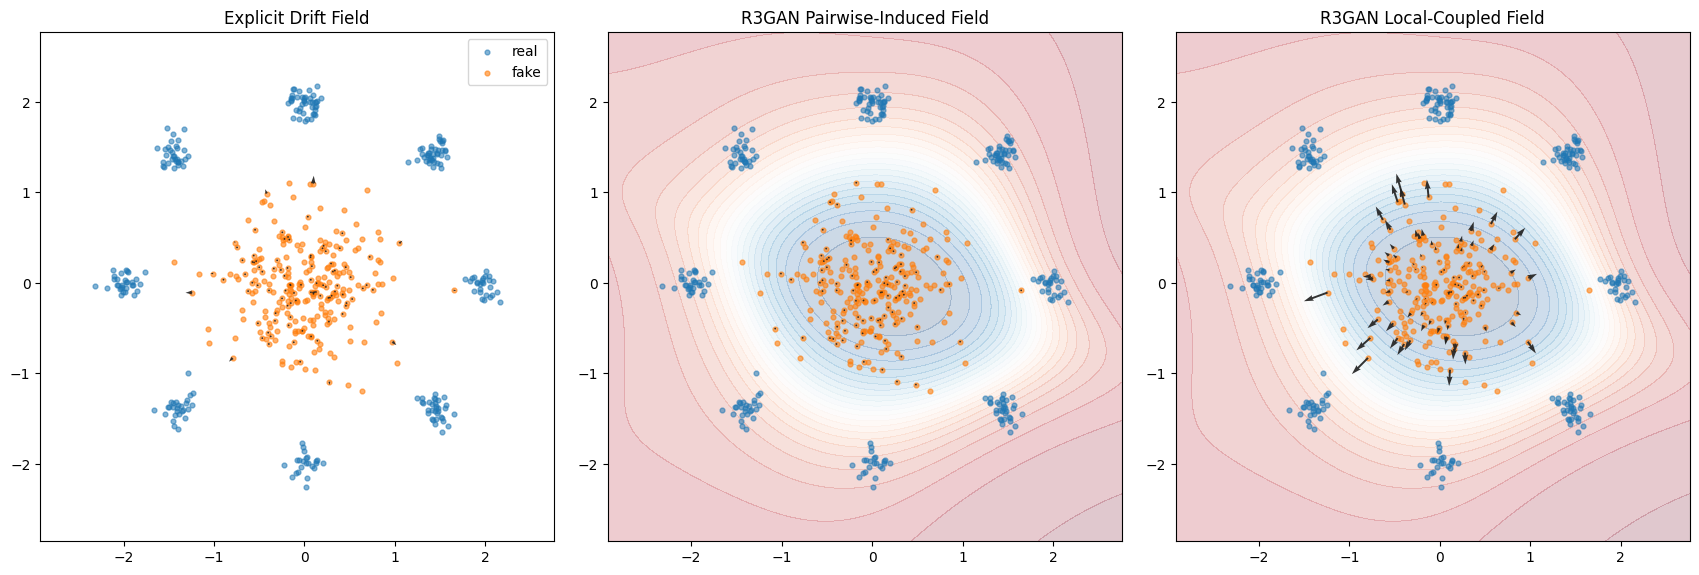

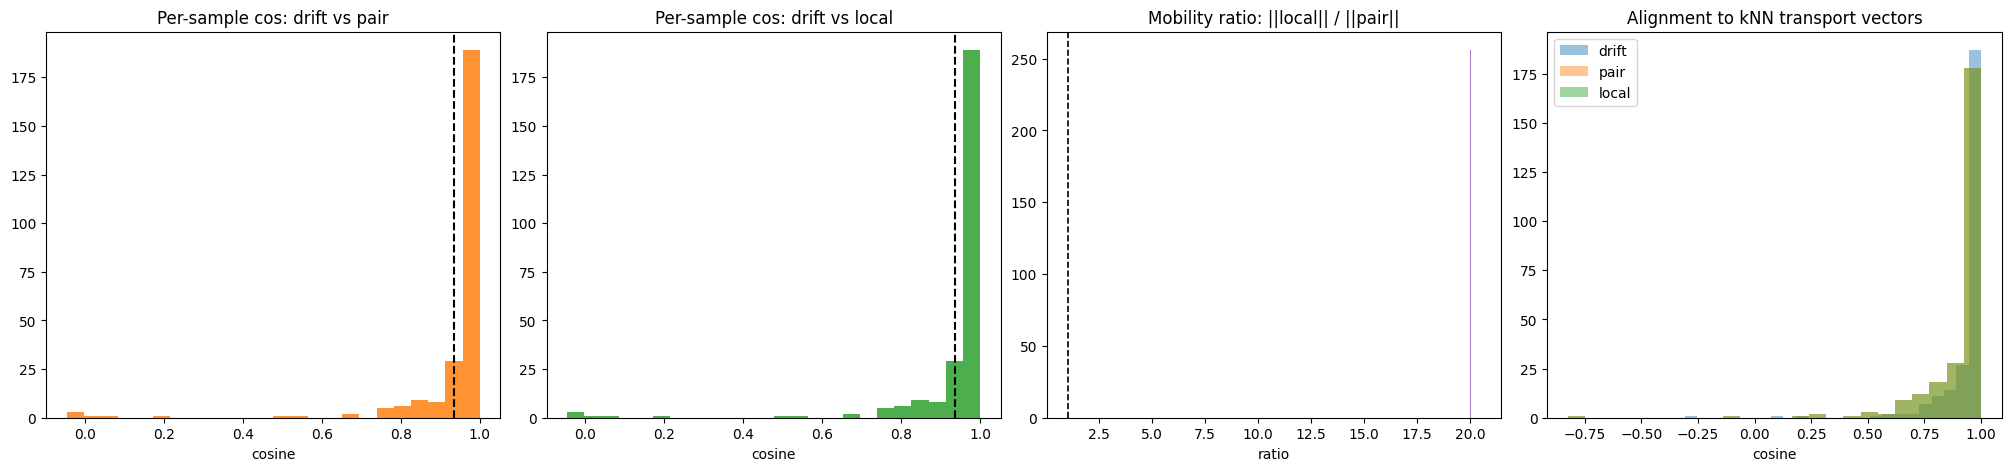

In [9]:
plot_field_triptych(result)
plot_scalar_diagnostics(result)


    scenario  drift_pair_cos  drift_local_cos  pair_local_cos  drift_transport_cos  pair_transport_cos  local_transport_cos  local_over_pair_mean_ratio
        ring           0.911            0.911             1.0                0.915               0.876                0.876                       3.500
   two_moons           0.590            0.590             1.0                0.576               0.418                0.418                       3.497
checkerboard           0.338            0.338             1.0                0.296               0.545                0.545                       3.528
      spiral           0.173            0.173             1.0                0.336               0.488                0.488                       3.535


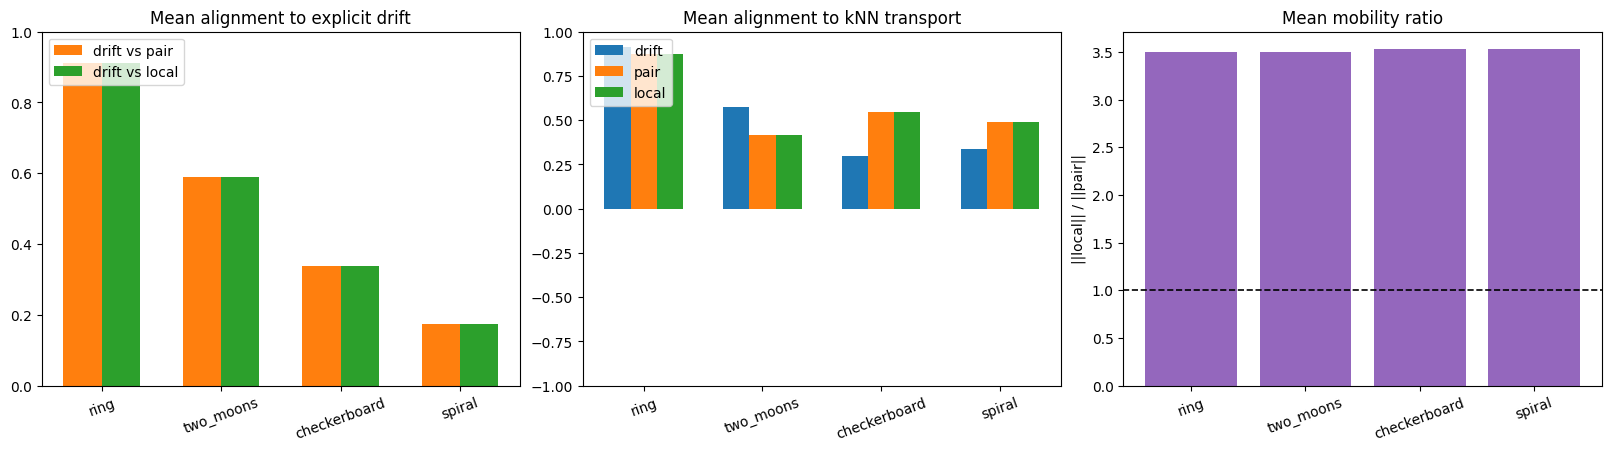

In [10]:
scenario_names = ["ring", "two_moons", "checkerboard", "spiral"]
sweep_results = [
    run_field_diagnostics(
        scenario=name,
        **sweep_profile,
    )
    for name in scenario_names
]
summary_rows = [item["summary"] for item in sweep_results]

summary_cols = [
    "scenario",
    "drift_pair_cos",
    "drift_local_cos",
    "pair_local_cos",
    "drift_transport_cos",
    "pair_transport_cos",
    "local_transport_cos",
    "local_over_pair_mean_ratio",
]

if HAS_PANDAS:
    summary_df = pd.DataFrame(summary_rows)[summary_cols]
    print(summary_df.round(3).to_string(index=False))
else:
    for row in summary_rows:
        print({key: round(row[key], 3) if isinstance(row[key], float) else row[key] for key in summary_cols})

plot_sweep_bars(summary_rows)


## Next steps

这个 notebook 现在已经能回答三类问题：

- 单个 toy 场景里，explicit drift 和 GAN-induced field 的方向有多接近
- local coupling 到底是在改方向，还是主要在放大 mobility
- 这个现象是不是只在 ring 上成立，还是在更难一点的 toy 几何上也成立

下一步如果你想把它进一步贴近当前主工程，有两个自然升级方向：

1. 用真实 checkpoint 里的 discriminator / generator 取代 toy critic
2. 把 coupling 的输入从 2D 坐标换成 `clean feature`，也就是更接近你现在的 local-coupled 设计
